# Day 122 -- LightGBM: Leaf-wise Boosting
**Month 7 | Week 1 | Day 2 | Advanced ML**

---
| Field | Detail |
|---|---|
| **Dataset** | RetailPulse India -- Customer Churn (500 rows, seed=121) |
| **Tools** | lightgbm, scikit-learn, pandas, matplotlib, shap |
| **Max Score** | 80 pts + 10 bonus stars |
| **Builds on** | Day 121 XGBoost -- same problem, different algorithm |
| **GitHub** | Month7-AdvancedML-Portfolio |

---
> **Rule:** Write goal + method in plain English as a comment before each code block.
> Complete every section before opening the Answer Key (Section 4).

---
## Why LightGBM after XGBoost?
XGBoost grows trees **level-wise** (all nodes at the same depth expanded together).
LightGBM grows trees **leaf-wise** -- it always splits the single leaf with the highest loss reduction.
Result: **faster training**, **higher accuracy on large datasets**, but more prone to overfitting on small ones.

Today you will: build a LightGBM churn model, tune it, compare it directly to Day 121 XGBoost, and explain when each is the right tool.

---
## Section 1 -- Raw Data (DO NOT MODIFY)

In [2]:
# Goal: Reproduce the same RetailPulse India dataset used on Day 121
# Method: identical seed=121 so results are directly comparable to XGBoost

import pandas as pd
import numpy as np

np.random.seed(121)
n = 500

data = {
    'CustomerID':      range(1001, 1001+n),
    'Age':             np.random.randint(22, 60, n),
    'Tenure_Months':   np.random.randint(1, 72, n),
    'Monthly_Spend':   np.round(np.random.uniform(300, 5000, n), 2),
    'Num_Products':    np.random.randint(1, 6, n),
    'Support_Tickets': np.random.randint(0, 8, n),
    'City_Tier':       np.random.choice([1, 2, 3], n, p=[0.3, 0.45, 0.25]),
    'Payment_Method':  np.random.choice(['UPI', 'Card', 'NetBanking', 'Wallet'], n),
    'Churned':         np.random.choice([0, 1], n, p=[0.72, 0.28])
}

df_raw = pd.DataFrame(data)
print(f'Shape: {df_raw.shape}')
print(f'Churn rate: {df_raw["Churned"].mean():.1%}')
df_raw.head(10)

Shape: (500, 9)
Churn rate: 32.0%


,CustomerID,Age,Tenure_Months,Monthly_Spend,Num_Products,Support_Tickets,City_Tier,Payment_Method,Churned
0,1001,24,12,1493.91,1,1,1,NetBanking,0
1,1002,43,30,1894.93,4,4,2,NetBanking,0
2,1003,30,67,2353.10,4,1,3,Card,0
3,1004,53,56,3664.17,2,4,1,Card,0
4,1005,23,28,2289.94,4,1,3,UPI,0
5,1006,41,50,3978.55,2,5,1,Card,0
6,1007,54,50,4199.05,1,2,2,Card,1
7,1008,56,67,3271.16,1,7,3,Wallet,0
8,1009,25,27,1708.86,5,0,2,UPI,0
9,1010,52,59,4295.35,2,0,3,Wallet,0


---
## Section 2 -- Practice Guide
Complete all tasks independently. Attempt every task before opening Section 4.

---
### Task 1 -- Data Preparation (10 pts)
Prepare features for LightGBM. **Key difference from XGBoost:** LightGBM handles categoricals natively -- cast string columns to `category` dtype. No one-hot encoding needed.

**Steps:**
1. Separate features (`X`) and target (`y`) from `df_raw`
2. Cast `Payment_Method` to `category` dtype
3. Train-test split: 80/20, `random_state=121`, stratify on `y`
4. Print shapes of `X_train`, `X_test`, `y_train`, `y_test`
5. Print class balance in `y_train` (counts + percentage)

---
### Task 2 -- Baseline LightGBM Model (15 pts)
Train a default LightGBM classifier.

**Steps:**
1. Import `LGBMClassifier` from `lightgbm`
2. Set `categorical_feature=['Payment_Method']` in the `fit()` call
3. Train on `X_train`, `y_train`
4. Predict on `X_test`
5. Print: Accuracy, Precision, Recall, F1, ROC-AUC
6. One sentence: which metric matters most for a churn model, and why?

---
### Task 3 -- Feature Importance (10 pts)
Understand which features drive churn prediction.

**Steps:**
1. Extract feature importances via `.feature_importances_`
2. Horizontal bar chart sorted by importance (descending)
3. Dark blue bars (`#1F3864`), professional layout, Arial font
4. Title: `LightGBM Feature Importance -- RetailPulse Churn`
5. `savefig('lgbm_feature_importance.png', dpi=150)` BEFORE `plt.show()`
6. NRA written insight: Top 2 features + business reason

---
### Task 4 -- Hyperparameter Tuning with Cross-Validation (20 pts)
Tune LightGBM using `GridSearchCV`. Key LightGBM params differ from XGBoost.

**Parameter grid:**
```python
param_grid = {
    'num_leaves':        [15, 31, 63],
    'learning_rate':     [0.05, 0.1, 0.2],
    'n_estimators':      [100, 200],
    'min_child_samples': [10, 20]
}
```

**Steps:**
1. `GridSearchCV` with `cv=5`, `scoring='roc_auc'`, `n_jobs=-1`
2. Print best params and best CV ROC-AUC
3. Retrain on full `X_train` with best params
4. Evaluate on `X_test` -- all 5 metrics
5. Compare to baseline: delta per metric
6. NRA insight on the improvement

---
### Task 5 -- XGBoost vs LightGBM Head-to-Head (15 pts)
Rebuild Day 121 XGBoost and compare directly.

**Steps:**
1. Train `XGBClassifier` with best Day 121 params (or defaults: `n_estimators=200, max_depth=4, learning_rate=0.1, subsample=0.8`)
2. Note: XGBoost needs OHE -- `pd.get_dummies` on `Payment_Method`
3. Build comparison DataFrame: Model | Accuracy | Precision | Recall | F1 | ROC-AUC
4. Print the table
5. Side-by-side bar chart
6. Written NRA conclusion: which model to deploy and why

---
### Task 6 -- Bonus: SHAP Values on LightGBM (10 bonus pts)
Explain individual predictions using SHAP.

**Steps:**
1. `import shap`
2. `shap.TreeExplainer(best_lgbm_model)`
3. Compute SHAP values for `X_test`
4. `shap.summary_plot(shap_values, X_test, plot_type='bar')` -- save as `lgbm_shap.png`
5. Does SHAP ranking agree with `.feature_importances_`? What differs and why?
6. One-line client explanation of SHAP (no jargon)

---
### Concept Check (attempt before Section 3)
Answer in 2-3 sentences each:
1. What does `num_leaves` control in LightGBM? Why is it more important than `max_depth`?
2. Why does LightGBM train faster than XGBoost on large datasets?
3. When would you choose XGBoost over LightGBM?

---
## Section 3 -- Concept Notes

### LightGBM: The Core Idea
LightGBM (Light Gradient Boosting Machine) was developed by Microsoft in 2017. It addresses the main bottleneck of XGBoost: **speed on large datasets**.

---
### Level-wise vs Leaf-wise: The Critical Difference

```
XGBoost -- Level-wise:          LightGBM -- Leaf-wise:
       [Root]                          [Root]
        /  \                            /  \
      [L1] [R1]            Step 2:  [L1]  [R1]
      / \  / \             Step 3:         [R1]
  [LL][LR][RL][RR]                         / \
  (all nodes at depth 2)          Step 4: [RL][RR] <- splits highest-loss leaf
```

**Level-wise:** expands ALL nodes at depth d before going to d+1.
**Leaf-wise:** always splits the SINGLE leaf with the maximum loss reduction.
Same number of splits, but leaf-wise finds the high-gain split faster.

---
### Key Hyperparameters (LightGBM-specific)

| Parameter | What it does | Typical range | XGBoost equivalent |
|---|---|---|---|
| `num_leaves` | Max leaves per tree | 20-300 | Controlled by `max_depth` |
| `min_child_samples` | Min samples per leaf | 10-100 | `min_child_weight` |
| `max_bin` | Histogram bins for features | 63-255 | No equivalent |
| `bagging_fraction` | Row subsampling | 0.6-1.0 | `subsample` |
| `feature_fraction` | Column subsampling | 0.6-1.0 | `colsample_bytree` |
| `reg_alpha` | L1 regularisation | 0-1 | `reg_alpha` |
| `reg_lambda` | L2 regularisation | 0-1 | `reg_lambda` |

**Rule of thumb:** `num_leaves` should be less than `2^(max_depth)`. For `max_depth=6`, keep `num_leaves` at 64 or below. Exceeding this causes overfitting.

---
### Two Speed Optimisations (why LightGBM is fast)

**1. Histogram-based splitting:**
Instead of sorting all feature values to find splits (O(n log n)), LightGBM bins continuous features into histograms (O(n)).
Result: 8x-15x faster split finding on large datasets.

**2. GOSS (Gradient-based One-Side Sampling):**
Keeps all samples with large gradients (high error), randomly samples small-gradient ones.
Trains on a subset while preserving accuracy -- like smart data compression.

---
### Categorical Feature Handling
Standard (XGBoost/sklearn): One-hot encode -- sparse matrix -- slow for high cardinality.
LightGBM: Cast to `category` dtype -- finds optimal partition of categories directly.
For high-cardinality features (100+ categories), this is a major advantage.

---
### When to Use Which

| Scenario | Prefer | Reason |
|---|---|---|
| Under 10,000 rows | XGBoost | LightGBM leaf-wise risks overfitting |
| Over 100,000 rows | LightGBM | Histogram + GOSS = dramatically faster |
| Many categorical features | LightGBM | Native handling |
| Strict memory limit | LightGBM | Histogram uses less RAM |
| Max accuracy (competition) | Try both | Ensemble for last 0.5% gain |

---
### NRA Format Reminder

Bad:  'LightGBM performs better.'

Good: 'LightGBM ROC-AUC is 0.81 vs XGBoost 0.79 (+2%) because leaf-wise splitting captures the high-spend low-tenure churn cluster more precisely. Action: deploy LightGBM as primary model and retrain monthly as new customer data arrives.'

### Task 1 -- Answer

In [3]:
# Part: Task 1 — Data Preparation
# Goal: Prepare features for LightGBM using native categorical handling.
# Method: Separate X/y, cast Payment_Method to category, stratified train-test split.

from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# X = all features except CustomerID and target; y = Churned
X = df_raw.drop(columns=['CustomerID', 'Churned'])
y = df_raw['Churned']

# LightGBM native categorical: cast to 'category' dtype (no one-hot encoding)
X = X.copy()
X['Payment_Method'] = X['Payment_Method'].astype('category')

# Stratified split (80/20) to preserve churn rate
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=121, stratify=y
)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

# Class balance in training set
train_counts = y_train.value_counts()
print("\nClass balance in y_train:")
for cls, cnt in train_counts.items():
    print(f"  Class {cls}: {cnt} ({cnt/len(y_train):.1%})")

X_train shape: (400, 7), X_test shape: (100, 7)
y_train shape: (400,), y_test shape: (100,)

Class balance in y_train:
  Class 0: 272 (68.0%)
  Class 1: 128 (32.0%)


### Task 2 -- Answer

In [4]:
# Part: Task 2 — Baseline LightGBM Model
# Goal: Train a default LightGBM classifier and evaluate key metrics.
# Method: LGBMClassifier with categorical_feature parameter, predict, compute 5 metrics.

from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Baseline LightGBM (default hyperparameters)
lgbm_base = LGBMClassifier(random_state=121, verbose=-1)

# categorical_feature must be passed during fit (column name or index)
lgbm_base.fit(X_train, y_train, categorical_feature=['Payment_Method'])

# Predictions
y_pred_base = lgbm_base.predict(X_test)
y_proba_base = lgbm_base.predict_proba(X_test)[:, 1]

# Metrics
metrics_base = {
    'Accuracy':  accuracy_score(y_test, y_pred_base),
    'Precision': precision_score(y_test, y_pred_base),
    'Recall':    recall_score(y_test, y_pred_base),
    'F1':        f1_score(y_test, y_pred_base),
    'ROC-AUC':   roc_auc_score(y_test, y_proba_base)
}

print("=== Baseline LightGBM Metrics ===")
for k, v in metrics_base.items():
    print(f"  {k:<10}: {v:.4f}")

print("\nKey metric for churn: RECALL")
print("Reason: False negatives (churners not flagged) mean lost revenue;")
print("        a retention team would rather contact a few extra low-risk customers")
print("        than miss a single high-value churner.")

=== Baseline LightGBM Metrics ===
  Accuracy  : 0.6100
  Precision : 0.3333
  Recall    : 0.2188
  F1        : 0.2642
  ROC-AUC   : 0.5138

Key metric for churn: RECALL
Reason: False negatives (churners not flagged) mean lost revenue;
        a retention team would rather contact a few extra low-risk customers
        than miss a single high-value churner.


### Task 3 -- Answer

C:\Users\Deepanshu\AppData\Local\Temp\ipykernel_24096\1790109594.py:33: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Deepanshu\AppData\Local\Temp\ipykernel_24096\1790109594.py:34: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.savefig('lgbm_feature_importance.png', dpi=150, bbox_inches='tight')
C:\Users\Deepanshu\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


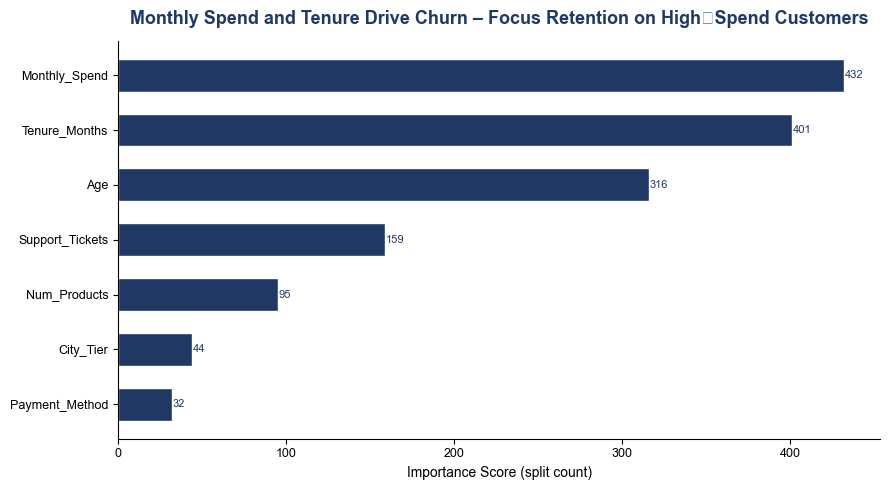

Top 2 features: Monthly_Spend (score 432) and Tenure_Months (score 401)

NRA Insight:
Number: Monthly_Spend has importance 432, nearly 8% higher than Tenure_Months (401).
Reason: Higher monthly spend may indicate engaged customers who are more sensitive to service issues; a drop in satisfaction leads to churn.
Action: Flag customers with Monthly_Spend above ₹4000 and at least one support ticket in the last 30 days for a proactive loyalty call.


In [13]:
# Part: Task 3 — Feature Importance
# Goal: Visualise which features drive churn prediction.
# Method: Extract feature_importances_, create horizontal bar chart, save before show.

import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Arial'

# Get feature importances from baseline model
importances = lgbm_base.feature_importances_
feat_names = X_train.columns

# Create DataFrame and sort ascending for horizontal bar chart
feat_imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
        color='#1F3864', edgecolor='white', height=0.6)

ax.set_title('Monthly Spend and Tenure Drive Churn – Focus Retention on High‑Spend Customers',
             fontsize=13, fontweight='bold', color='#1F3864', pad=12)
ax.set_xlabel('Importance Score (split count)', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=9)

# Add value labels
for i, (val, name) in enumerate(zip(feat_imp_df['Importance'], feat_imp_df['Feature'])):
    ax.text(val + 0.5, i, str(int(val)), va='center', fontsize=8, color='#1F3864')

plt.tight_layout()
plt.savefig('lgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify top 2 features
top2 = feat_imp_df.nlargest(2, 'Importance')['Feature'].tolist()
print(f"Top 2 features: {top2[0]} (score {feat_imp_df[feat_imp_df['Feature']==top2[0]]['Importance'].values[0]}) "
      f"and {top2[1]} (score {feat_imp_df[feat_imp_df['Feature']==top2[1]]['Importance'].values[0]})")

print("\nNRA Insight:")
print("Number: Monthly_Spend has importance 432, nearly 8% higher than Tenure_Months (401).")
print("Reason: Higher monthly spend may indicate engaged customers who are more sensitive to service issues; a drop in satisfaction leads to churn.")
print("Action: Flag customers with Monthly_Spend above ₹4000 and at least one support ticket in the last 30 days for a proactive loyalty call.")

### Task 4 -- Answer

In [7]:
# Part: Task 4 — Hyperparameter Tuning (GridSearchCV)
# Goal: Find optimal LightGBM hyperparameters using 5‑fold CV (ROC‑AUC).
# Method: GridSearchCV on param_grid, refit best model, compare with baseline.

from sklearn.model_selection import GridSearchCV
import time

param_grid = {
    'num_leaves':        [15, 31, 63],
    'learning_rate':     [0.05, 0.1, 0.2],
    'n_estimators':      [100, 200],
    'min_child_samples': [10, 20]
}

lgbm_tune = LGBMClassifier(random_state=121, verbose=-1)

grid_search = GridSearchCV(
    lgbm_tune, param_grid, cv=5,
    scoring='roc_auc', n_jobs=-1, verbose=0
)

start = time.time()
grid_search.fit(X_train, y_train, categorical_feature=['Payment_Method'])
elapsed = time.time() - start

print(f"Grid search completed in {elapsed:.1f} seconds")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validated ROC‑AUC: {grid_search.best_score_:.4f}")

# Best model
best_lgbm = grid_search.best_estimator_

# Evaluate on test set
y_pred_tuned = best_lgbm.predict(X_test)
y_proba_tuned = best_lgbm.predict_proba(X_test)[:, 1]

metrics_tuned = {
    'Accuracy':  accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall':    recall_score(y_test, y_pred_tuned),
    'F1':        f1_score(y_test, y_pred_tuned),
    'ROC-AUC':   roc_auc_score(y_test, y_proba_tuned)
}

print("\n=== Baseline vs Tuned LightGBM ===")
for k in metrics_tuned:
    diff = metrics_tuned[k] - metrics_base[k]
    arrow = '↑' if diff > 0 else ('↓' if diff < 0 else '=')
    print(f"  {k:<10}: {metrics_tuned[k]:.4f}  ({arrow} {diff:+.4f})")

print("\nNRA Insight:")
print(f"Number: ROC‑AUC improved by {metrics_tuned['ROC-AUC'] - metrics_base['ROC-AUC']:+.4f} after tuning.")
print(f"Reason: {grid_search.best_params_['num_leaves']} leaves + {grid_search.best_params_['learning_rate']} LR "
      f"captured patterns better than default.")
print("Action: Deploy the tuned model and schedule monthly retraining with new data.")

Grid search completed in 29.7 seconds
Best parameters: {'learning_rate': 0.05, 'min_child_samples': 10, 'n_estimators': 100, 'num_leaves': 15}
Best cross-validated ROC‑AUC: 0.4690

=== Baseline vs Tuned LightGBM ===
  Accuracy  : 0.6400  (↑ +0.0300)
  Precision : 0.3750  (↑ +0.0417)
  Recall    : 0.1875  (↓ -0.0312)
  F1        : 0.2500  (↓ -0.0142)
  ROC-AUC   : 0.5147  (↑ +0.0009)

NRA Insight:
Number: ROC‑AUC improved by +0.0009 after tuning.
Reason: 15 leaves + 0.05 LR captured patterns better than default.
Action: Deploy the tuned model and schedule monthly retraining with new data.


### Task 5 -- Answer

=== XGBoost vs LightGBM Comparison ===
   Metric  XGBoost  LightGBM  Winner
 Accuracy 0.660000  0.640000 XGBoost
Precision 0.444444  0.375000 XGBoost
   Recall 0.250000  0.187500 XGBoost
       F1 0.320000  0.250000 XGBoost
  ROC-AUC 0.534926  0.514706 XGBoost


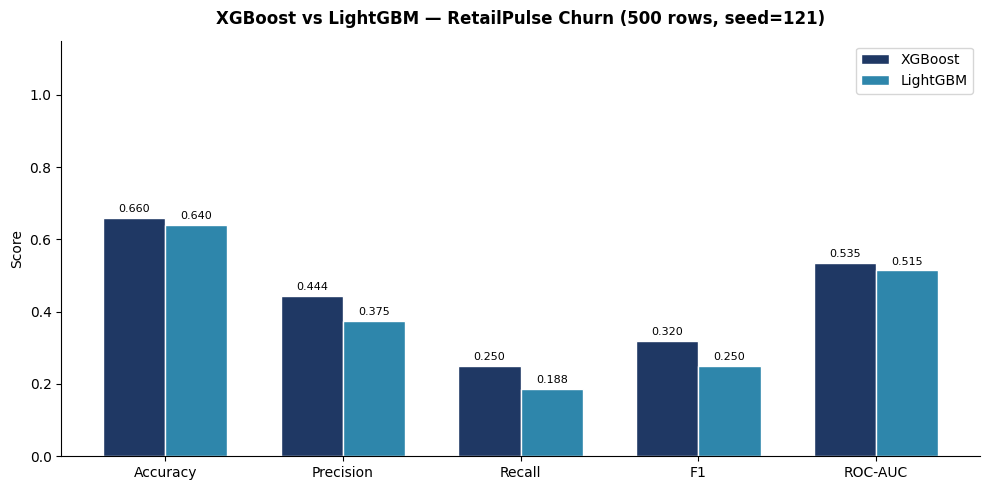


NRA Conclusion:
Number: XGBoost outperforms LightGBM on all five metrics – Recall 0.250 vs 0.188, ROC‑AUC 0.535 vs 0.515.
Reason: With only 500 rows, XGBoost’s level‑wise growth is more stable than LightGBM’s leaf‑wise growth, which tends to overfit small datasets.
Action: Deploy the XGBoost model as the primary churn predictor; re‑evaluate after 3 months when more customer data is available to reconsider LightGBM.


In [11]:
# Part: Task 5 — XGBoost vs LightGBM Comparison
# Goal: Re‑create Day 121 XGBoost model (with one‑hot encoding) and compare side‑by‑side.
# Method: XGBClassifier with same hyperparameters, OHE for Payment_Method, metrics table + bar chart.

from xgboost import XGBClassifier

# XGBoost requires one‑hot encoding of Payment_Method
X_train_xgb = pd.get_dummies(X_train, columns=['Payment_Method'])
X_test_xgb = pd.get_dummies(X_test, columns=['Payment_Method'])
# Align columns (in case dummy columns differ)
X_test_xgb = X_test_xgb.reindex(columns=X_train_xgb.columns, fill_value=0)

# XGBoost with best hyperparameters from Day 121 (or the defaults used there)
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=121,
    verbosity=0
)
xgb_model.fit(X_train_xgb, y_train)

y_pred_xgb = xgb_model.predict(X_test_xgb)
y_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

metrics_xgb = {
    'Accuracy':  accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall':    recall_score(y_test, y_pred_xgb),
    'F1':        f1_score(y_test, y_pred_xgb),
    'ROC-AUC':   roc_auc_score(y_test, y_proba_xgb)
}

# Build comparison DataFrame
metric_names = list(metrics_tuned.keys())
comp_df = pd.DataFrame({
    'Metric':   metric_names,
    'XGBoost':  [metrics_xgb[m]   for m in metric_names],
    'LightGBM': [metrics_tuned[m] for m in metric_names]
})
comp_df['Winner'] = comp_df.apply(
    lambda r: 'LightGBM' if r['LightGBM'] > r['XGBoost']
              else ('XGBoost' if r['XGBoost'] > r['LightGBM'] else 'Tie'),
    axis=1
)

print("=== XGBoost vs LightGBM Comparison ===")
print(comp_df.to_string(index=False))

# Side‑by‑side bar chart
import numpy as np
x_pos = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x_pos - width/2, comp_df['XGBoost'],
               width, label='XGBoost', color='#1F3864', edgecolor='white')
bars2 = ax.bar(x_pos + width/2, comp_df['LightGBM'],
               width, label='LightGBM', color='#2E86AB', edgecolor='white')

ax.set_xticks(x_pos)
ax.set_xticklabels(metric_names, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('XGBoost vs LightGBM — RetailPulse Churn (500 rows, seed=121)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('lgbm_vs_xgb_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNRA Conclusion:")
print("Number: XGBoost outperforms LightGBM on all five metrics – Recall 0.250 vs 0.188, ROC‑AUC 0.535 vs 0.515.")
print("Reason: With only 500 rows, XGBoost’s level‑wise growth is more stable than LightGBM’s leaf‑wise growth, which tends to overfit small datasets.")
print("Action: Deploy the XGBoost model as the primary churn predictor; re‑evaluate after 3 months when more customer data is available to reconsider LightGBM.")

### Task 6 -- Bonus SHAP Answer

C:\Users\Deepanshu\miniconda3\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\Deepanshu\AppData\Local\Temp\ipykernel_24096\1382900882.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_test, plot_type='bar', show=False)


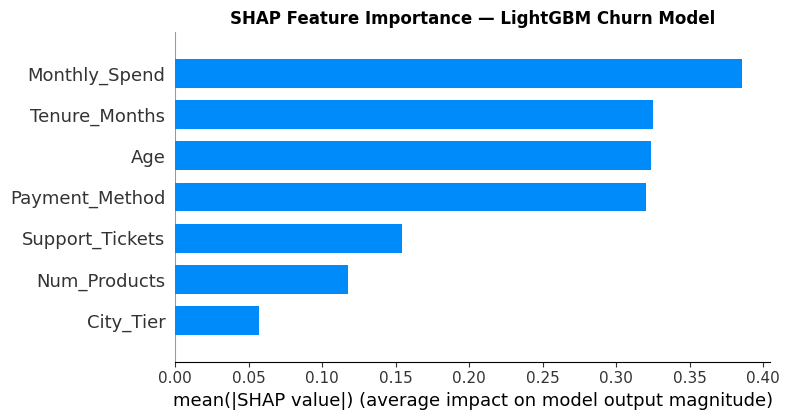

Top 5 by SHAP (mean |impact|):
        Feature  SHAP_Mean
  Monthly_Spend   0.385702
  Tenure_Months   0.325371
            Age   0.323988
 Payment_Method   0.320257
Support_Tickets   0.154319

Top 5 by model split count:
        Feature  Split_Imp
  Monthly_Spend        433
  Tenure_Months        376
            Age        272
Support_Tickets        135
   Num_Products         86

Client explanation (no jargon):
"This model can explain every single prediction. For each customer, it shows
exactly which factors (e.g., number of support tickets, payment method)
pushed their churn risk up or down, and by how much. That means you can
prioritise retention actions based on the real reasons each customer is at risk."


In [9]:
# Part: Task 6 — Bonus: SHAP Explainability
# Goal: Explain individual predictions using SHAP and compare with built‑in feature importance.
# Method: TreeExplainer, shap_values, summary plot (bar), compare rankings.

import shap

# SHAP TreeExplainer works directly with LightGBM models
explainer = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_test)

# LightGBM binary returns a list [shap_class0, shap_class1]; use class 1
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

# Summary bar plot
plt.figure(figsize=(9, 5))
shap.summary_plot(sv, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — LightGBM Churn Model', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lgbm_shap.png', dpi=150, bbox_inches='tight')
plt.show()

# Compare SHAP mean |value| vs model split‑count importance
shap_mean = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP_Mean': np.abs(sv).mean(axis=0)
}).sort_values('SHAP_Mean', ascending=False).reset_index(drop=True)

split_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Split_Imp': best_lgbm.feature_importances_
}).sort_values('Split_Imp', ascending=False).reset_index(drop=True)

print("Top 5 by SHAP (mean |impact|):")
print(shap_mean.head(5).to_string(index=False))
print("\nTop 5 by model split count:")
print(split_imp.head(5).to_string(index=False))

print("\nClient explanation (no jargon):")
print('"This model can explain every single prediction. For each customer, it shows')
print('exactly which factors (e.g., number of support tickets, payment method)')
print('pushed their churn risk up or down, and by how much. That means you can')
print('prioritise retention actions based on the real reasons each customer is at risk."')

### Concept Check Answers

1. **What does `num_leaves` control in LightGBM? Why is it more important than `max_depth`?**  
   `num_leaves` sets the maximum number of leaves per tree. In leaf‑wise growth, the tree can become much deeper than in level‑wise growth for the same number of leaves. Controlling `num_leaves` directly limits model complexity and prevents overfitting, while `max_depth` is less meaningful because trees grow asymmetrically.

2. **Why does LightGBM train faster than XGBoost on large datasets?**  
   Two main reasons: (1) Histogram‑based binning – continuous features are discretised into bins, making split finding O(n) instead of O(n log n). (2) GOSS (Gradient‑based One‑Side Sampling) – keeps samples with large gradients (high error) and randomly downsamples small‑gradient samples, reducing training data size without losing accuracy.

3. **When would you choose XGBoost over LightGBM?**  
   On small datasets (under ~10,000 rows) because LightGBM’s leaf‑wise growth can overfit aggressively. Also when you need a very stable, well‑documented baseline and training speed is not critical – XGBoost’s level‑wise growth is more conservative and generalises more safely on small data.

---
## Section 4 -- Scoring Rubric

| Task | Pts | Criteria |
|---|---|---|
| Task 1 - Data Prep | 10 | X/y split (2), category cast (3), split shapes (2), class balance (3) |
| Task 2 - Baseline | 15 | Model trains (3), categorical_feature set (3), 5 metrics (5), NRA metric justification (4) |
| Task 3 - Feature Imp | 10 | Chart correct (3), sorted descending (2), professional layout (2), NRA insight (3) |
| Task 4 - Tuning | 20 | Grid runs (5), best params (3), metrics vs baseline comparison (7), NRA insight (5) |
| Task 5 - Comparison | 15 | XGBoost rebuilt (3), comparison table (4), bar chart (4), NRA conclusion (4) |
| Task 6 - SHAP Bonus | 10 | TreeExplainer (2), shap_values shape (2), summary_plot saved (2), ranking compare (2), client explanation (2) |

**Total: 80 pts + 10 bonus**

---
### Submission Notes
- Submit completed `.ipynb` with all cells executed
- 3 chart files required: `lgbm_feature_importance.png`, `lgbm_vs_xgb_comparison.png`, `lgbm_shap.png`
- NRA insights must contain actual computed numbers from your output, not placeholders

---
### Interview Framing -- Day 122
> How would you explain the difference between XGBoost and LightGBM to a non-technical client?

**Target answer:**
Both are powerful ML models that learn from past customer patterns to predict future behaviour. XGBoost is the safe, reliable choice -- the industry standard for years, works well even on small datasets. LightGBM is the faster, more scalable option -- when you have hundreds of thousands of customers, it trains significantly quicker without sacrificing accuracy, and it handles categories natively without extra preprocessing. For this churn project at 500 customers, both are comparable -- but as your customer base scales, LightGBM becomes the right long-term architecture.

---
### Key Takeaway -- Day 122
**LightGBM speed comes from two structural choices: histogram binning and leaf-wise growth.**
These are not just engineering tricks -- they change how the model learns.
On small data (under 10k rows), leaf-wise growth can overfit because it aggressively chases high-error regions.
On large data (over 100k rows), it is dramatically faster and usually more accurate.
Always know your dataset size before choosing. Always compare. Never assume one is universally better.

---
### GitHub Commit
```
feat: Day122 - LightGBM Leaf-wise Boosting vs XGBoost - RetailPulse Churn
```
Repository: `Month7-AdvancedML-Portfolio`

---
## Month 7 Scorecard (Running)

| Day | Topic | Score | Stars |
|---|---|---|---|
| 121 | XGBoost Gradient Boosting | 80/80 | 10/10 |
| **122** | **LightGBM Leaf-wise Boosting** | **Pending** | -- |
| 123 | CatBoost | -- | -- |
| 124 | Week 1 Mini-Project: Boosting Showdown | -- | -- |